**UPLOAD THE FILE**

In [ ]:
import pandas as pd
df = pd.read_csv('/content/TYPES CANCER DATASET (2).csv')
df.head()

,NAT_590G>A,NAT_857G>A,NAT_481C>T,NAT_803A>G,NQO1_609C>T,SULT1A1_638G>A,EPMX1_337T>C,EPHX1_415A>G,CLASS,SEX,AGE,Smoking,pack years,Histology
0,M,H,W,M,W,W,W,H,1,0,70,0,50.0,1
1,H,W,W,H,W,W,H,H,0,0,75,0,17.5,0
2,M,H,H,W,W,H,H,H,1,0,52,0,50.0,1
3,H,H,H,H,H,W,H,W,0,0,42,0,24.0,0
4,H,W,M,W,W,W,M,W,1,0,60,0,137.5,3


**CHECK MISSING VALUES**

In [ ]:
df.isnull().sum()

,0
NAT_590G>A,0
NAT_857G>A,0
NAT_481C>T,0
NAT_803A>G,0
NQO1_609C>T,0
SULT1A1_638G>A,0
EPMX1_337T>C,0
EPHX1_415A>G,0
CLASS,0
SEX,0


**STANDARD SCALING**

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df[['AGE', 'pack years']] = scaler.fit_transform(df[['AGE', 'pack years']])

**ENCODING SNPS COLUMNS**

In [ ]:
snp_cols = [
    'NAT_590G>A', 'NAT_857G>A', 'NAT_481C>T', 'NAT_803A>G',
    'NQO1_609C>T', 'SULT1A1_638G>A', 'EPMX1_337T>C', 'EPHX1_415A>G'
]
mapping = {'W': 0, 'H': 1, 'M': 2}
df = df.replace(mapping)
df.head()

/tmp/ipykernel_811/1914876139.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace(mapping)


,NAT_590G>A,NAT_857G>A,NAT_481C>T,NAT_803A>G,NQO1_609C>T,SULT1A1_638G>A,EPMX1_337T>C,EPHX1_415A>G,CLASS,SEX,AGE,Smoking,pack years,Histology
0,2,1,0,2,0,0,0,1,1,0,1.019311,0,1.245004,1
1,1,0,0,1,0,0,1,1,0,0,1.477381,0,-0.133296,0
2,2,1,1,0,0,1,1,1,1,0,-0.629742,0,1.245004,1
3,1,1,1,1,1,0,1,0,0,0,-1.545883,0,0.142364,0
4,1,0,2,0,0,0,2,0,1,0,0.103171,0,4.955813,3


**REMOVE CLASS COLUMN**

In [ ]:
df = df.drop('CLASS', axis=1)

**REMOVE ROWS CONTAINING VALUES 1 AND 2 IN HISTOLOGY COLUMN**

In [ ]:
# ================= STEP 1: ensure numeric =================
df['Histology'] = pd.to_numeric(df['Histology'], errors='coerce')
# ================= STEP 2: keep only 0 and 1 =================
df = df[df['Histology'].isin([0, 3])].copy()
# ================= STEP 3: reset index =================
df.reset_index(drop=True, inplace=True)
# ================= STEP 4: verify =================
print(df['Histology'].value_counts())

Histology
0.0    550
3.0    127
Name: count, dtype: int64


**CHANGE THE VALUE OF 3 TO 1**

In [ ]:
df['Histology'] = df['Histology'].replace(3, 1)

**CLASS WEIGHTS**

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
# Step 1: Select target column
y = df['Histology']
# Step 2: Remove missing values (important)
y = y.dropna()
# Step 3: Get unique classes
classes = np.unique(y)
# Step 4: Compute class weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y
)
# Step 5: Convert to dictionary
class_weights_dict = dict(zip(classes, class_weights))
print(class_weights_dict)

{np.float64(0.0): np.float64(0.6154545454545455), np.float64(1.0): np.float64(2.6653543307086616)}


**TRAIN TEST THE MODEL**

In [ ]:
from sklearn.model_selection import train_test_split
# Features and target
X = df.drop('Histology', axis=1)
y = df['Histology']
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # important for imbalance
)

**APPLY RANDOM FOREST MODEL**

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Model
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight=class_weights_dict
)

# Train
rf.fit(X_train, y_train)

# Predict
y_pred = rf.predict(X_test)

# Result
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8161764705882353
              precision    recall  f1-score   support

         0.0       0.82      0.99      0.90       110
         1.0       0.67      0.08      0.14        26

    accuracy                           0.82       136
   macro avg       0.74      0.53      0.52       136
weighted avg       0.79      0.82      0.75       136



**APPLY CATBOOST MODEL**

In [ ]:
# Install (if needed)
!pip install catboost

from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, classification_report

# Class weights in list form [w0, w1]
cb_weights = [class_weights[0], class_weights[1]]

# Model
cb = CatBoostClassifier(
    iterations=300,
    depth=6,
    learning_rate=0.05,
    class_weights=cb_weights,
    verbose=0,
    random_state=42
)

# Train
cb.fit(X_train, y_train)

# Predict
y_pred = cb.predict(X_test)

# Result
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.7 MB/s eta 0:00:00
Accuracy: 0.75
              precision    recall  f1-score   support

         0.0       0.85      0.85      0.85       110
         1.0       0.35      0.35      0.35        26

    accuracy                           0.75       136
   macro avg       0.60      0.60      0.60       136
weighted avg       0.75      0.75      0.75       136



**APPLY XGBOOST**

In [ ]:
# Install (if needed)
!pip install xgboost

from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

# scale_pos_weight = majority / minority
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# Model
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42
)

# Train
xgb.fit(X_train, y_train)

# Predict
y_pred = xgb.predict(X_test)

# Result
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:26:49] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy: 0.7647058823529411
              precision    recall  f1-score   support

         0.0       0.86      0.85      0.85       110
         1.0       0.39      0.42      0.41        26

    accuracy                           0.76       136
   macro avg       0.63      0.63      0.63       136
weighted avg       0.77      0.76      0.77       136



**APPLY GRADIENT BOOSTING**

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report

# Sample weights (class imbalance handle)
sample_weights = y_train.map(class_weights_dict)

# Model
gb = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

# Train
gb.fit(X_train, y_train, sample_weight=sample_weights)

# Predict
y_pred = gb.predict(X_test)

# Result
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.6617647058823529
              precision    recall  f1-score   support

         0.0       0.86      0.69      0.77       110
         1.0       0.29      0.54      0.38        26

    accuracy                           0.66       136
   macro avg       0.58      0.61      0.57       136
weighted avg       0.75      0.66      0.69       136



**APPLY SUPPORT VECTOR MACHINE**

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler

# Scaling (IMPORTANT)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model
svm = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    class_weight=class_weights_dict,
    probability=True,
    random_state=42
)

# Train
svm.fit(X_train_scaled, y_train)

# Predict
y_pred = svm.predict(X_test_scaled)

# Result
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7352941176470589
              precision    recall  f1-score   support

         0.0       0.90      0.75      0.82       110
         1.0       0.39      0.65      0.49        26

    accuracy                           0.74       136
   macro avg       0.64      0.70      0.65       136
weighted avg       0.80      0.74      0.76       136



**APPLY K-NEAREST NEIGHBORS**

Accuracy: 0.8382352941176471
              precision    recall  f1-score   support

         0.0       0.84      0.99      0.91       110
         1.0       0.83      0.19      0.31        26

    accuracy                           0.84       136
   macro avg       0.84      0.59      0.61       136
weighted avg       0.84      0.84      0.79       136



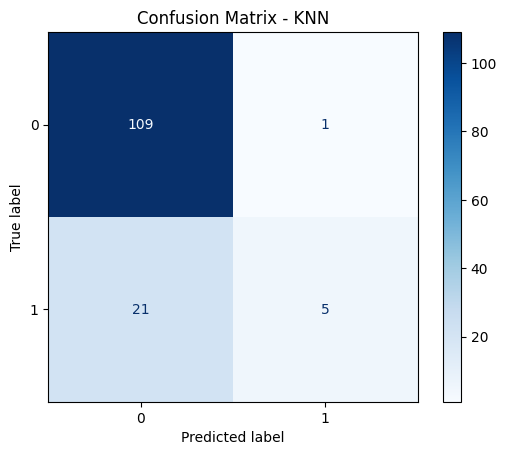

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(


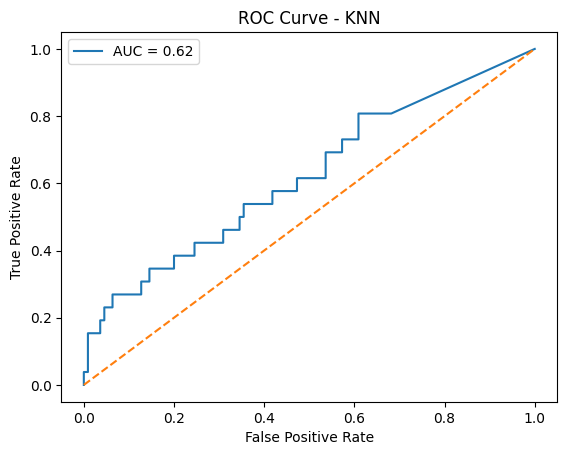

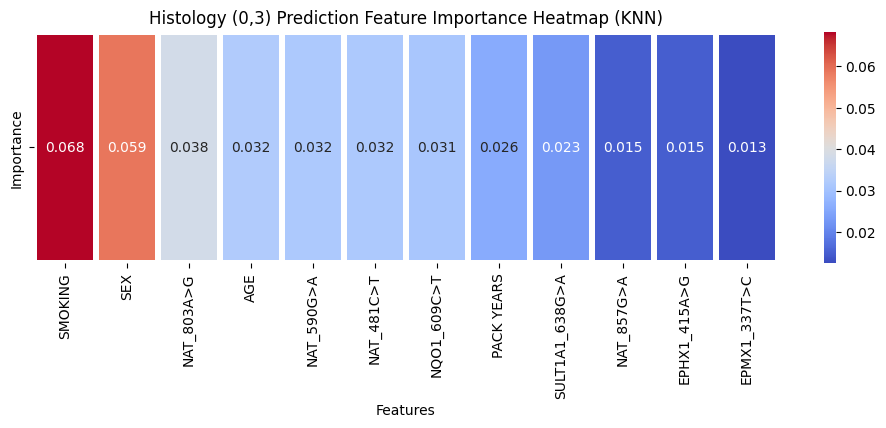

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler

# Scaling (IMPORTANT)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model
knn = KNeighborsClassifier(
    n_neighbors=5,
    weights='distance',   # helps with imbalance
    metric='euclidean'
)

# Train
knn.fit(X_train_scaled, y_train)

# Predict
y_pred = knn.predict(X_test_scaled)

# Result
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')

plt.title("Confusion Matrix - KNN")
plt.show()

from sklearn.metrics import roc_curve, auc
y_prob = knn.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - KNN")
plt.legend()

plt.show()

from sklearn.inspection import permutation_importance
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Compute permutation importance
result = permutation_importance(
    knn,
    X_test_scaled,
    y_test,
    n_repeats=10,
    random_state=42
)

# Convert to dataframe
feat_df = pd.DataFrame({
    'Features': X_train.columns,
    'Importance': result.importances_mean
})

# CONVERT FEATURES INTO CAPITALS
feat_df['Features'] = feat_df['Features'].str.upper()

# Sort
feat_df = feat_df.sort_values(by='Importance', ascending=False)

# Convert to heatmap format
heatmap_data = feat_df.set_index('Features').T

# Plot heatmap
plt.figure(figsize=(12, 3))

sns.heatmap(
    heatmap_data,
    annot=True,
    cmap='coolwarm',
    linewidths=3,
    linecolor='white'
)

plt.title("Histology (0,3) Prediction Feature Importance Heatmap (KNN)")

plt.show()

**APPLY GAUSSIAN NAIVE BAYES**

In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report

# Sample weights (imbalance handle)
sample_weights = y_train.map(class_weights_dict)

# Model
gnb = GaussianNB()

# Train
gnb.fit(X_train, y_train, sample_weight=sample_weights)

# Predict
y_pred = gnb.predict(X_test)

# Result
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.6764705882352942
              precision    recall  f1-score   support

         0.0       0.90      0.67      0.77       110
         1.0       0.33      0.69      0.45        26

    accuracy                           0.68       136
   macro avg       0.62      0.68      0.61       136
weighted avg       0.79      0.68      0.71       136



**APPLY LOGISTIC REGRESSION**

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler

# Scaling (IMPORTANT)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model
lr = LogisticRegression(
    class_weight=class_weights_dict,
    max_iter=1000,
    random_state=42
)

# Train
lr.fit(X_train_scaled, y_train)

# Predict
y_pred = lr.predict(X_test_scaled)

# Result
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7352941176470589
              precision    recall  f1-score   support

         0.0       0.90      0.75      0.82       110
         1.0       0.39      0.65      0.49        26

    accuracy                           0.74       136
   macro avg       0.64      0.70      0.65       136
weighted avg       0.80      0.74      0.76       136



**ROC CURVE**

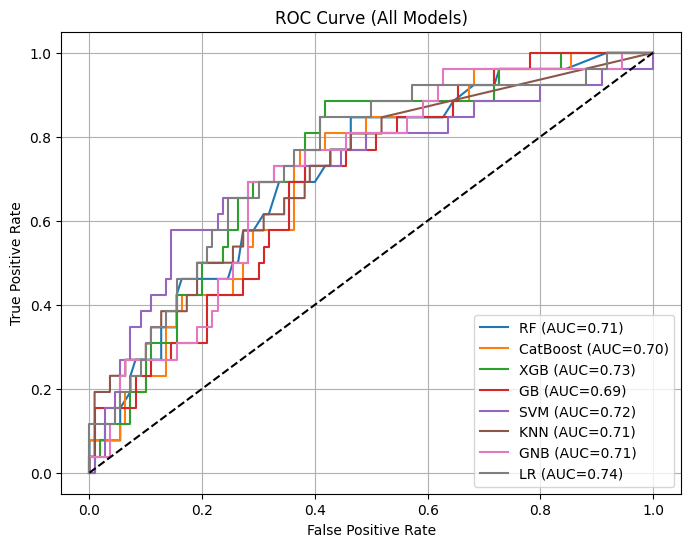

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(8,6))

# ================= RANDOM FOREST =================
y_prob = rf.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, label=f"RF (AUC={auc(fpr,tpr):.2f})")

# ================= CATBOOST =================
y_prob = cb.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, label=f"CatBoost (AUC={auc(fpr,tpr):.2f})")

# ================= XGBOOST =================
y_prob = xgb.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, label=f"XGB (AUC={auc(fpr,tpr):.2f})")

# ================= GRADIENT BOOSTING =================
y_prob = gb.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, label=f"GB (AUC={auc(fpr,tpr):.2f})")

# ================= SVM =================
y_prob = svm.predict_proba(X_test_scaled)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, label=f"SVM (AUC={auc(fpr,tpr):.2f})")

# ================= KNN =================
y_prob = knn.predict_proba(X_test_scaled)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, label=f"KNN (AUC={auc(fpr,tpr):.2f})")

# ================= NAIVE BAYES =================
y_prob = gnb.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, label=f"GNB (AUC={auc(fpr,tpr):.2f})")

# ================= LOGISTIC REGRESSION =================
y_prob = lr.predict_proba(X_test_scaled)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, label=f"LR (AUC={auc(fpr,tpr):.2f})")

# ================= FINAL PLOT =================
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (All Models)")
plt.legend()
plt.grid()

plt.show()


**ACCURACY TABLE**

In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = []

def evaluate_model(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    results.append([name, acc, prec, rec, f1])

# ================= MODELS =================
evaluate_model("Random Forest", y_test, rf.predict(X_test))
evaluate_model("CatBoost", y_test, cb.predict(X_test))
evaluate_model("XGBoost", y_test, xgb.predict(X_test))
evaluate_model("Gradient Boosting", y_test, gb.predict(X_test))
evaluate_model("SVM", y_test, svm.predict(X_test_scaled))
evaluate_model("KNN", y_test, knn.predict(X_test_scaled))
evaluate_model("Naive Bayes", y_test, gnb.predict(X_test))
evaluate_model("Logistic Regression", y_test, lr.predict(X_test_scaled))

# ================= TABLE =================
df_metrics = pd.DataFrame(
    results,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1-Score"]
)

# Sort by best model
df_metrics = df_metrics.sort_values(by="Accuracy", ascending=False)

print(df_metrics)

                 Model  Accuracy  Precision    Recall  F1-Score
5                  KNN  0.838235   0.833333  0.192308  0.312500
0        Random Forest  0.816176   0.666667  0.076923  0.137931
2              XGBoost  0.764706   0.392857  0.423077  0.407407
1             CatBoost  0.750000   0.346154  0.346154  0.346154
7  Logistic Regression  0.735294   0.386364  0.653846  0.485714
4                  SVM  0.735294   0.386364  0.653846  0.485714
6          Naive Bayes  0.676471   0.333333  0.692308  0.450000
3    Gradient Boosting  0.661765   0.291667  0.538462  0.378378
